# Bayesovská analýza generalizovaného Monty Hallova problému

Tato simulace modeluje obecnou variantu **problému dveří s pokladem** pro $N$ dveří. 
Pravidla generalizace jsou následující:
1. Hráč si vybere jedny z $N$ dveří.
2. Hostitel (který ví, kde je poklad) následně otevře $N-2$ dveří, za kterými poklad není. 
3. Zavřené zůstanou pouze dvoje dveře: původní volba hráče a jedny další dveře.
4. Hráč má možnost svou volbu změnit.

### Definice problému pro $N$ dveří
Nechť $D_i$ značí jev, že poklad je za dveřmi $i \in \{1, 2, \dots, N\}$. 
Apriorní pravděpodobnost, že poklad je za libovolnými dveřmi, je pro všechny stejná:
$$P(D_i) = \frac{1}{N}$$

### Aktualizace po informaci od hostitele
Předpokládejme, že hráč vybere dveře č. 1 ($D_1$). Hostitel poté otevře množinu $N-2$ prázdných dveří, kterou si označíme jako jev $H$. Zavřené zbudou dveře č. 1 a dveře č. 2.

Pomocí Bayesova teorému odvodíme posteriorní pravděpodobnosti pro obě zbývající možnosti:

1. **Pravděpodobnost pro původní volbu (Strategie Stay):**
   Pokud je poklad skutečně za dveřmi č. 1, hostitel musí náhodně vybrat $N-2$ dveří k otevření ze zbylých $N-1$ dveří. Pravděpodobnost, že vybere konkrétní kombinaci $H$, je $P(H|D_1) = \frac{1}{N-1}$.
   Celková pravděpodobnost, že nastane jev $H$, sečtená přes všechny možnosti, je $P(H) = \frac{1}{N-1}$.
   
   $$P(D_1|H) = \frac{P(H|D_1)P(D_1)}{P(H)} = \frac{\frac{1}{N-1} \cdot \frac{1}{N}}{\frac{1}{N-1}} = \frac{1}{N}$$

2. **Pravděpodobnost pro zbývající dveře (Strategie Switch):**
   Pokud je poklad za dveřmi č. 2, hostitel *nemá na výběr*. Nesmí otevřít dveře č. 1 (volba hráče) ani dveře č. 2 (poklad). Musí s jistotou otevřít přesně ty dveře, které tvoří množinu $H$. Tedy věrohodnost $P(H|D_2) = 1$.
   
   $$P(D_2|H) = \frac{P(H|D_2)P(D_2)}{P(H)} = \frac{1 \cdot \frac{1}{N}}{\frac{1}{N-1}} = \frac{N-1}{N}$$

### Závěr
Pro obecný počet dveří $N$ zůstává pravděpodobnost původní volby vždy **$1/N$**. Naproti tomu strategie změny do sebe "nasaje" veškerou zbývající pravděpodobnost ze všech otevřených dveří a poskytuje tak šanci na výhru **$(N-1)/N$**.
Čím více dveří ve hře je, tím více se pravděpodobnost výhry po změně blíží k jistotě (100 %).

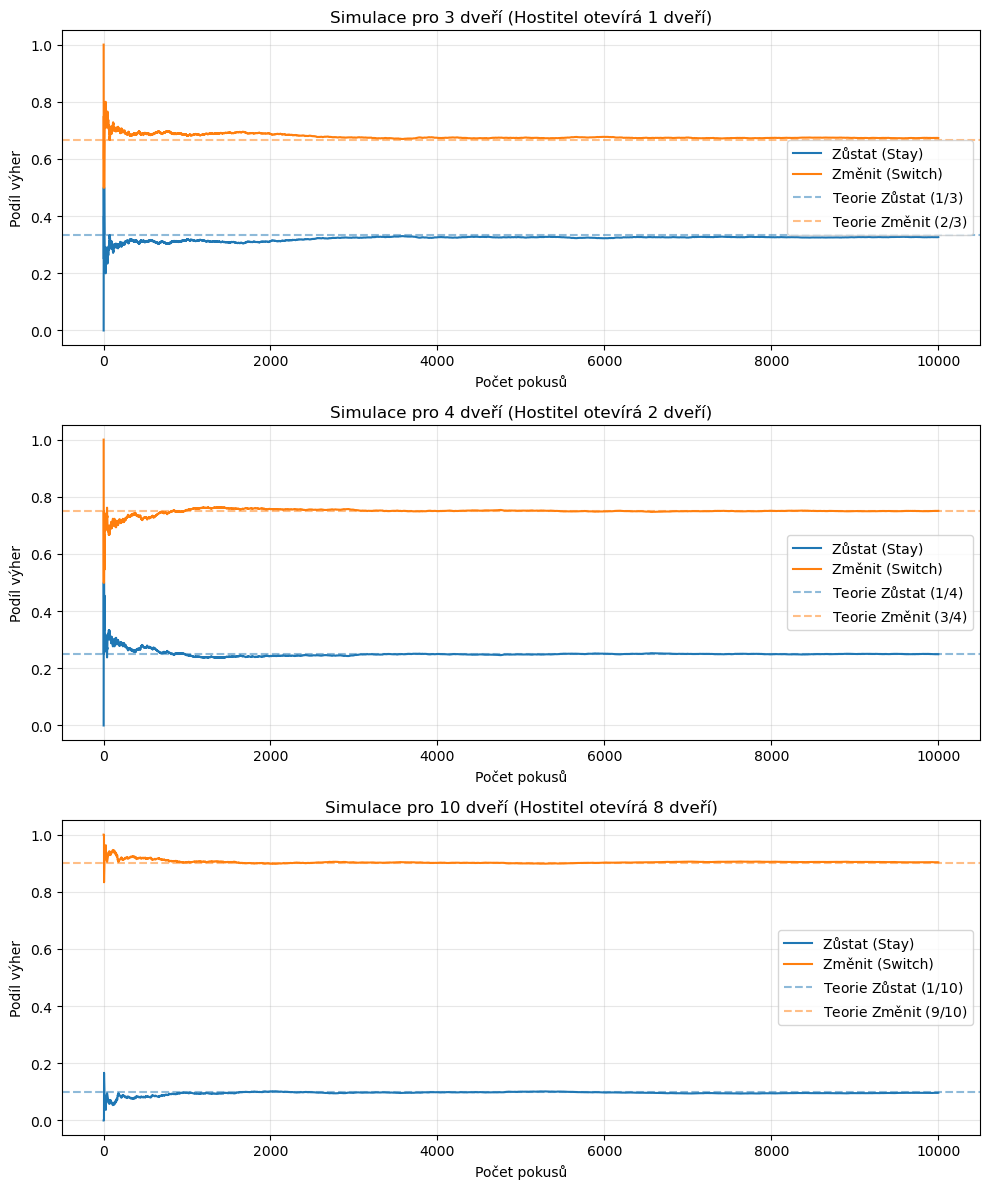

In [12]:
import random
import matplotlib.pyplot as plt

# ==========================================
# KONFIGURACE SIMULACE
# ==========================================
POCET_POKUSU = 10000
SEZNAM_POCET_DVERI = [3, 4, 10]  # Můžete libovolně přidávat/odebírat počty dveří
# ==========================================

def simulace_monty_hall(n_pokusu, n_dveri):
    vyhry_beze_zmeny = []
    vyhry_se_zmenou = []
    
    kumulativni_beze_zmeny = 0
    kumulativni_se_zmenou = 0
    
    for i in range(1, n_pokusu + 1):
        dvere = list(range(n_dveri))
        poklad = random.choice(dvere)
        volba_hrace = random.choice(dvere)
        
        # Hostitel ví, kde je poklad.
        # Otevře všechny ostatní dveře (N-2) tak, aby zůstaly zavřené pouze 2: 
        # volba hráče a jedny další dveře (které mohou, ale nemusí skrývat poklad).
        if volba_hrace == poklad:
            # Pokud hráč trefil poklad rovnou, hostitel náhodně vybere jedny
            # zbývající dveře, které NEOTEVŘE. Ostatní otevře.
            zbyvajici = [d for d in dvere if d != volba_hrace]
            dvere_k_otevreni = random.sample(zbyvajici, n_dveri - 2)
        else:
            # Pokud hráč netrefil poklad, hostitel MUSÍ nechat zavřené dveře
            # s pokladem a otevře všechny ostatní.
            dvere_k_otevreni = [d for d in dvere if d != volba_hrace and d != poklad]
            
        # Vykreslení strategií
        
        # Strategie 1: Beze změny (Stay)
        if volba_hrace == poklad:
            kumulativni_beze_zmeny += 1
            
        # Strategie 2: Se změnou (Switch) - hráč přejde na jediné další zavřené dveře
        zmenena_volba = [d for d in dvere if d != volba_hrace and d not in dvere_k_otevreni][0]
        if zmenena_volba == poklad:
            kumulativni_se_zmenou += 1
            
        vyhry_beze_zmeny.append(kumulativni_beze_zmeny / i)
        vyhry_se_zmenou.append(kumulativni_se_zmenou / i)
        
    return vyhry_beze_zmeny, vyhry_se_zmenou

# Vykreslení všech grafů podle konfigurace
pocet_grafu = len(SEZNAM_POCET_DVERI)
fig, axes = plt.subplots(pocet_grafu, 1, figsize=(10, 4 * pocet_grafu))

# Zajištění, že axes je vždy list (i když je jen jeden graf)
if pocet_grafu == 1:
    axes = [axes]

for idx, n_dveri in enumerate(SEZNAM_POCET_DVERI):
    ax = axes[idx]
    vyhry_beze_zmeny, vyhry_se_zmenou = simulace_monty_hall(POCET_POKUSU, n_dveri)
    
    # Teoretické pravděpodobnosti
    teoreticka_beze_zmeny = 1 / n_dveri
    teoreticka_se_zmenou = (n_dveri - 1) / n_dveri
    
    ax.plot(range(1, POCET_POKUSU + 1), vyhry_beze_zmeny, label='Zůstat (Stay)', color='tab:blue')
    ax.plot(range(1, POCET_POKUSU + 1), vyhry_se_zmenou, label='Změnit (Switch)', color='tab:orange')
    
    ax.axhline(y=teoreticka_beze_zmeny, color='tab:blue', linestyle='--', alpha=0.5, 
               label=f'Teorie Zůstat ($1/{n_dveri}$)')
    ax.axhline(y=teoreticka_se_zmenou, color='tab:orange', linestyle='--', alpha=0.5, 
               label=f'Teorie Změnit (${n_dveri-1}/{n_dveri}$)')
    
    ax.set_title(f'Simulace pro {n_dveri} dveří (Hostitel otevírá {n_dveri - 2} dveří)')
    ax.set_xlabel('Počet pokusů')
    ax.set_ylabel('Podíl výher')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='center right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()